In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from config import Config
from piramida import run_pyramid
import matplotlib.pyplot as plt

In [2]:
os.listdir('../Ships')

['00031f145.jpg',
 '00a9fb8a3.jpg',
 '00e5fb033.jpg',
 '020a5f9f6.jpg',
 '0005d01c8.jpg',
 '0005d6d95.jpg',
 '020cb7b89.jpg',
 '00de449b2.jpg']

In [5]:
import numpy as np
from PIL import Image

def ucitaj_sliku(putanja, ciljana_velicina=(200, 200)):
    slika = Image.open(putanja)
    
    #pretvori u grayscale ako nije
    if slika.mode != 'L':
        slika = slika.convert('L')
    
    #smanji na 200x200 kao u radu
    slika = slika.resize(ciljana_velicina, Image.LANCZOS)
    
    #pretvori u numpy i normaliziraj
    slika_array = np.array(slika, dtype=np.float64) / 255.0
    
    return slika_array

# ucitaj i testiraj
slika = ucitaj_sliku('../Ships/020a5f9f6.jpg')
print(f"Shape: {slika.shape}")
print(f"Min: {slika.min():.3f}, Max: {slika.max():.3f}")

config = Config(koristiti_laplacian=False)
scores = run_pyramid(slika, config)

Shape: (200, 200)
Min: 0.008, Max: 0.969
Razina 0: img=(25, 25), sumnjivi shape=None
Razina 0: slika 25x25, m_ukupno=62
  globalni_sigma: 0.674670
  Raspon scoreova: 0.0174 - 0.7853
  99. centil score-ova: 0.6090
  50. centil score-ova: 0.0479
Razina 1: img=(50, 50), sumnjivi shape=(25, 25)
Razina 1: slika 50x50, m_ukupno=825
  globalni_sigma: 0.001975
  Raspon scoreova: 0.7268 - 0.9998
  99. centil score-ova: 0.9943
  50. centil score-ova: 0.9062
Razina 2: img=(100, 100), sumnjivi shape=(50, 50)
Razina 2: slika 100x100, m_ukupno=5000
  globalni_sigma: 0.000230
  Raspon scoreova: 0.1660 - 1.0000
  99. centil score-ova: 0.9646
  50. centil score-ova: 0.4701
Razina 3: img=(200, 200), sumnjivi shape=(100, 100)
Razina 3: slika 200x200, m_ukupno=20000
  globalni_sigma: 0.000063
  Raspon scoreova: 0.0140 - 0.9996
  99. centil score-ova: 0.5906
  50. centil score-ova: 0.0629


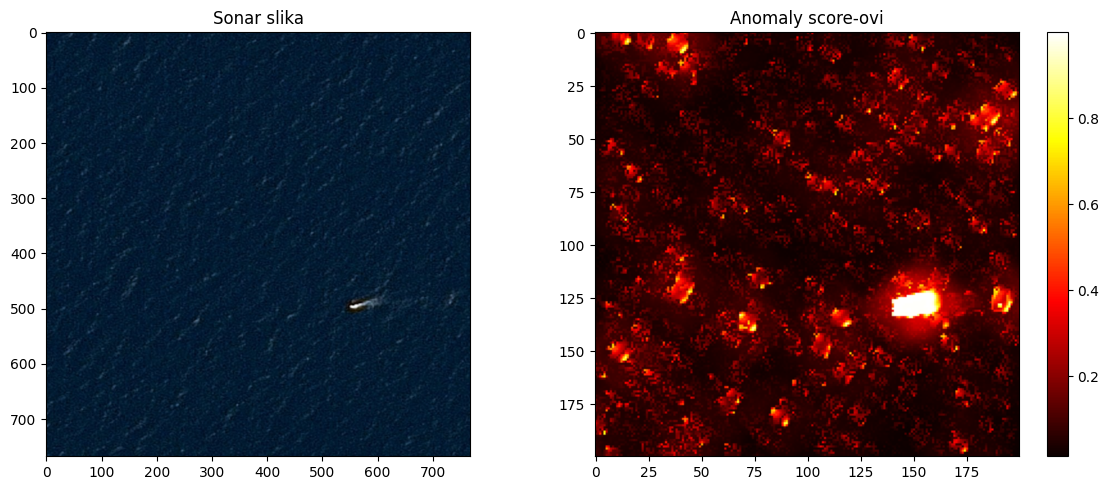

In [6]:
slika_og = Image.open('../Ships/020a5f9f6.jpg')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(slika_og, cmap='gray')
axes[0].set_title('Sonar slika')
axes[1].imshow(scores, cmap='hot')
axes[1].set_title('Anomaly score-ovi')
plt.colorbar(axes[1].images[0], ax=axes[1])
plt.tight_layout()
plt.savefig('rezultati.png')
plt.show()